# Tutorial H<sup>2</sup>MM analysis for PIE/nsALEX systems

To start with H<sup>2</sup>MM analysis, an appropriate burst selection is necessary.

The cell below sets up a starting point to enter into H<sup>2</sup>MM analysis.

# Tutorial H<sup>2</sup>MM analysis for PIE/nsALEX systems

To start with H<sup>2</sup>MM analysis, an appropriate burst selection is necessary.

The cell below sets up a starting point to enter into H<sup>2</sup>MM analysis.

In [1]:
from itertools import chain, product

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import smfbursts as smf
import H2MMbursts as bhm

raw = smf.photonHDF5.load('data/HP3_TE300_SPC630.hdf5')
data = smf.photonHDF5.regularize_dets(raw)
dbs = smf.fretfactory.make_bg(data, period=60.0, tail_min=5e-4, auto_threshold=True, func=smf.bg.exp_mlefit, F_bg=1.7)
smf.fretfactory.make_burst_search(bg=dbs['bg'], m=10, F=6.0, update=dbs, nbva=5)
gate_All = smf.make_geq_gate(dbs['NphDex_raw'], 50) & smf.make_geq_gate(dbs['NphAA_raw'], 25)
smf.fretfactory.apply_gate(dbs, gate_All);

## Standard H<sup>2</sup>MM analysis

H<sup>2</sup>MM analysis is designed for the characterization of within burst dynamics.
This is usually seen as a sign of conformational dynamics for FRET labeled biomolecules.

A brief outline of the pipeline of the H<sup>2</sup>MM analysis pipelife proceeds as follows:
1. Before H<sup>2</sup>MM
    1. Burst search
        - Identify single molecule bursts
        - trim and select (gating) burst population to those of interest (and significance, ie sufficient size)
    2. Qualitative Checks
        - Histograms and scatterplots of PR/E and S to determine likely states
        - BVA as indicator of and estimate degree of within burst dynamics
        - may choose to refine gating based on burst characteristics
2. H<sup>2</sup>MM model optimization
    - Optimize models of transition rates and emission probabilities of different states
    - *Viterbi* path to determine most likely state path for a given model
3. Compare and select ideal model with statistical discriminators
    - $BIC$, $BIC_{path}$ plateu/minimize around ideal model
4. Visualize burst and dwell-wise parameters

Note that in the outline above step 1 (and it's substeps) are **not** H<sup>2</sup>MM.
These are things commonly done in burst analysis, and can be considered "pre" H<sup>2</sup>MM analysis.
BVA is not strictly required, but highly recomended as an initial "gut-check" to see if dynamics are expected.
However, since H<sup>2</sup>MM (especially mpH2<sup>2</sup>MM) can also detect photo-physical states,
it can still be useful to run H<sup>2</sup>MM on seemingly static samples, 


### Qualitative checks

Based on the outline above the burst search has been performed, but the rest of the "pre" checks have not been done. 

This section demonstrates the rest of the "pre" checks that should be done before H<sup>2</sup>MM analysis.
To see when H<sup>2</sup>MM analysis actually begins skip to the next section.
The following demonstrates the common checks done for responsible H<sup>2</sup>MM analysis.

> **Note**
> 
> In this example, all thresholds, gates etc. have been chosen before hand to be ideal based on the test data set.
> In real analysis, these are not known, and thus the following is more the minimum acceptable pre-checks.

First, we plot the E/S scatter to see the distribution of bursts.

(-0.1, 1.1)

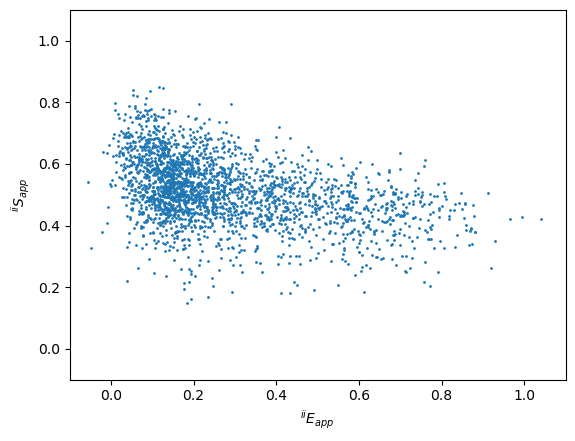

In [2]:
smf.plot.scatter(data, dbs['E_bg'], dbs['S_bg'], s=1.0)
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])

Next, it is a good idea to check burst variance analysis.
This provides a qualatative check for within burst dynamics.



(0.0, 0.4)

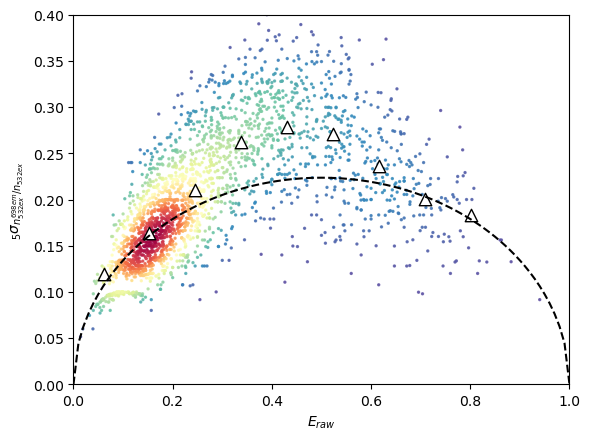

In [3]:
n = 5
x_bva = np.arange(0,1.01,0.01)
y_bva = np.sqrt((x_bva*(1-x_bva))/n)

smf.plot.scatter(data, dbs['E_raw'], dbs['BVA5'], point_func=smf.plot.density_kde, s=2.0, alpha=0.8, cmap='Spectral_r')
smf.plot.scatter_meaninterval(data, dbs['E_raw'], dbs['BVA5'], marker='^', c='w', ec='k', s=80)
plt.plot(x_bva, y_bva, ls='--', c='k')
plt.xlim([0,1])
plt.ylim([0.0, 0.4])

Note the presence of a significant number of bursts above the static FRET line.

> **Note**
>
> In [Torella 2011](https://doi.org/10.1016/j.bpj.2011.01.066)
> recomended a more computationally expensive Monte-Carlo approach to compute a static FRET confidence interval.
> This is not implemented in smfbursts or burstH2MM, but should be relatively straitforward to implement.
> Typcially however, as BVA is already a somewhat qualatative method, using the analytical expression above is sufficient.

### H<sup>2</sup>MM optimization

Typical H<sup>2</sup>MM anlaysis starts with optimizing a series of models of increasing numbers of states.
For this, the `bhm.StatePath.optimize_models()` method is used.

This method will optimize models, and return `StatePath` based `Param`s for each optimized model.

The first two arguments `origin` and `bursts` which define the source data and the burst selection, 
as `PhotonData`/`PhotonDataList` and `Param` respectively.

The next argument is `streams`, which defines which streams of photons are given to H<sup>2</sup>MM. 

In this example, we will use the selection used in [Harris 2022](https://doi.org/10.1038/s41467-022-28632-x).
This means our streams will be $n_{Dex}^{Dem}$, $n_{Dex}^{Aem}$ and $n_{1ex}^{1em}$, ie
```python
streams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em'))
```

> In the original H<sup>2</sup>MM paper [Prichi 2016](https://doi.org/10.1021/acs.jpcb.6b10726), it was demonstrated with only 2 color FRET, 
and any alternating excitation streams were discarded, ie $n_{Dex}^{Dem}$ and $n_{Dex}^{Aem}$.
>
> In a [Harris 2022](https://doi.org/10.1038/s41467-022-28632-x) (which also introduced the `H2MM_C` package on which `burstH2MM` depends)
> it was shown that for a typical PIE measurement, also incorporating the acceptor excitation stream ($n_{Aex}^{Aem}$).
>It was also argued that any "relevant" stream will likely improve the results. 
> In other words, the more information, the better, so if a given stream is expected to differ in properties between states, it is best to include it.

The `origin`, `bursts` and `streams` arguments define the input data to the H<sup>2</sup>MM algorithm.
The remaining arguments define optimization limits parameters.
These are

1. `conv_crit='pathBIC'` criterion to use to determine if optimizations have converged
2. `to_state=4` minimum number of states to optimize, regardless of convergence criterion
3. `min_states=1` which number of states to begin optimizing at
4. `max_states=8` maximum number of states to optimize, regardless of convergence criterion
5. additional kwargs are assumed to be inputs to
   [H2MM_C.h2mm_model.optimize()](https://h2mmpythonlib.readthedocs.io/en/latest/Documentation.html#H2MM_C.h2mm_model.optimize)
   Some useful parameters are:
    1. `max_iter` set the maximum number of iterations per optimization
    2. `converged_min` set the minimum difference in loglikelihood between rounds to consder model optimized
   
Below is a typical example optimization:

In [4]:
streams = (smf.PhSel('0ex0em'), smf.PhSel('0ex1em'), smf.PhSel('1ex1em')) # streams to submit to H2MM analysis
statepaths = bhm.StatePath.optimize_models(
    data, dbs['bursts'], streams=streams,conv_crit='BICph', thresh=0.005
)

The model converged after 3 iterations
The model converged after 91 iterations
The model converged after 223 iterations
The model converged after 215 iterations
Optimization reached maximum number of iterations


The return value is a list of `Param` objects, based on the `StatePath` table class.

Because H<sup>2</sup>MM models typically need to be optimized first, it is rare to directly create a H<sup>2</sup>MM parameter.
Rather, we let `bhm.StatePath.optimize_models` create them from the optimized models.

Each `Param` in the list has 1 more state than the last.
Now the optimized models are examine to determine which one is the ideal model, neither over nor under fit.

After that, the ideal model can be interogated for its meaning regarding within burst dynamcs and states.

### Comparing models

There are several different statistical discriminators used for comparing the "quality" of the model.
These are:
1. $BIC$ Bayes Information Criterion of model, the loglikelhood penalized for number of parameters and datapoints
2. $ICL$ Integrated Complete Likelihood, an output of the *Viterbi* algorithm assessing the forward probabiliy of the path
3. $BIC_{path}$ BIC of most likely state-path based on *Viterbi* algorithm

The order reflects how conservative these estimators are.
Generally it is best to take all information, both from statistical discriminators, and the models themselves,
into account before selecting the ideal model.

> **Note**
>
> The `conv_crit` selection `bhm.StatePath.optimize_models()` uses the selected discriminator to determine whether to stop or not.

We can plot the statistical discriminators for a sequence of `StatePath` `Param`s with the `bhm.plot.scatter_<discr>()` functions.

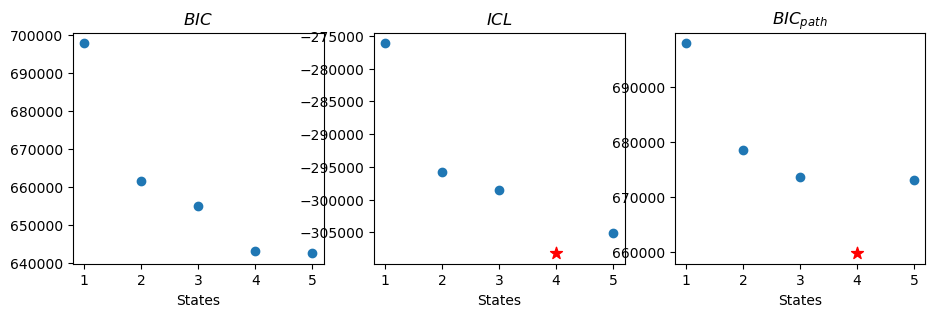

In [5]:
fig, ax = plt.subplots(1,3, figsize=(11,3))
bhm.plot.scatter_BIC(data, statepaths, ax=ax[0])
bhm.plot.scatter_ICL(data, statepaths, ax=ax[1])
bhm.plot.scatter_pathBIC(data, statepaths, ax=ax[2]);

Another option is the `bhm.plot.scatter_<discr>ph()` functions, where the discriminator is divided by the number of photons in the data set.
Since the data is the same, this only rescales the values of the discriminators.
However, since the likelihood scales roughly with the number of photons, this division is a rough normalization for the values.

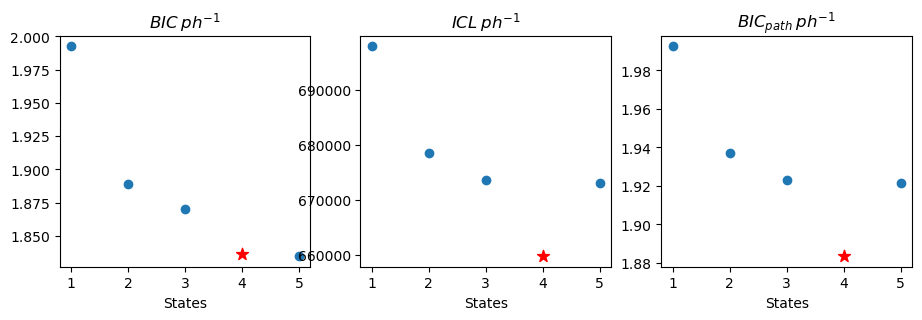

In [6]:
fig, ax = plt.subplots(1,3, figsize=(11,3))
bhm.plot.scatter_BICph(data, statepaths, ax=ax[0])
bhm.plot.scatter_ICLph(data, statepaths, ax=ax[1])
bhm.plot.scatter_pathBICph(data, statepaths, ax=ax[2]);

With the example data set, it is very clear that the 4-state model (therefore index 3 in `statepaths`) is the best model.

Note that this is an ideal example, and demonstrates "ideal" behavior.
The $BIC$ typically "plateaus" so the ideal model is the start of the plataue, while $ICL$ and $BIC_{path}$ typically minimize at the ideal model.
When the plateau and minima are different, or perhaps the $ICL$ or $BIC_{path}$ plateau, 
the model selection requires examining each model and prior knowledge of the system to make the selection.

In the end, model selection is always a matter of the users judgement.

### Examining results

Now we can examine the meaning of the ideal model

> **Note**
>
> In cases where model selection is unclear, the visualizations/methods in the following section
> are very useful to understand each model, and decide which one "makes the most sense"

The name `StatePath` was chosen because most of the columns of this table are based on results from the *Viterbi* algorithm

The `StatePath` uses the *Viterbi* algorithm to determine the most like state of each photon
that was submitted H<sup>2</sup>MM processing (ie if the photon belongs to one of the photon streams in `streams`).

Conscutive photons in the same state define "dwells", which behave much in the same way like bursts.

The `Dwells` table is the `burstH2MM` representation of these dwells, `Dwells` tables have all the same columns as `Bursts` tables.

By creating a `Dwells` param we can see how well the dwells match the predicted states.
Each dwell has a state, an this is represented in the column `state`, 
so in the code below a dictionary is created for storing H<sup>2</sup>MM `Param` and `Columns`,
which will include the state column.

In [7]:
dhmm = bhm.fretfactory.make_dwell_dict(statepaths[3])

Plotting dwells colored by the state column visualizes how each state behaves compared to the others.

(0.0, 1.0)

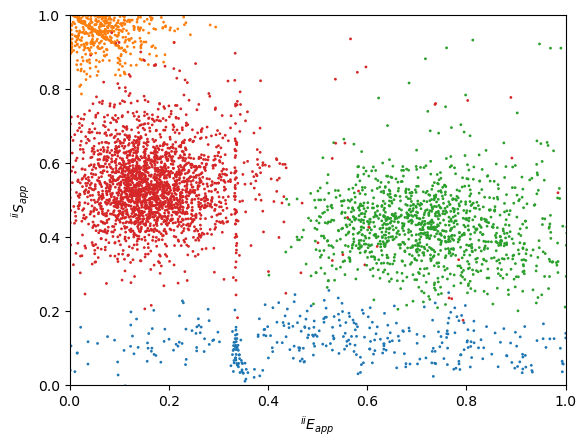

In [8]:
smf.plot.scatter(data, dhmm['E_bg'], dhmm['S_bg'], 
                 point_func=smf.plot.colorcategory, point_cols=dhmm['State'], 
                 s=1.0, point_kwargs={'cmap':mpl.colormaps['tab10']})

plt.xlim([0,1])
plt.ylim([0,1])

This also helps to identify states (and give them human readable names)

A simple "trick" to remember the states is to plot some invisible points with the colors you know will be used in the plot
(ie with the same color map), and plot the legend:

(0.0, 1.0)

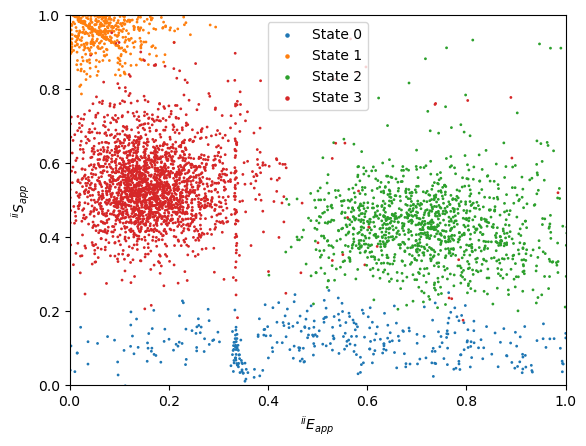

In [9]:
smf.plot.scatter(data, dhmm['E_bg'], dhmm['S_bg'], 
                 point_func=smf.plot.colorcategory, point_cols=dhmm['State'], 
                 s=1.0, point_kwargs={'cmap':mpl.colormaps['tab10']})

## for loop to add color labels ##
# note: you can replace plt. with ax. in this when needing to specify a specific axes
for i in range(dhmm['statepath'].params['model'].nstate):
    # 'tab10' colormap is the same as mpl.colormaps['tab10'] and 
    # calling with ([i]) returns color value of given number
    plt.scatter(np.nan, np.nan, s=5.0, 
                c=mpl.colormaps['tab10']([i]), label=f'State {i}')
plt.legend()
# set reasonable bounds, exclude outlier dwells
plt.xlim([0,1])
plt.ylim([0,1])

The `bhm.plot.scatter_model` and `bhm.scatter_model_trans_arrows()` overlay the
model-predicted values and transitions with transition rates predicted by the model respectively.

This is very useful to overlay over the burst plot.

> **Note**
>
> The `bhm.plot.scatter_model` and `bhm.scatter_model_trans_arrows()`
> works on any ratio based column, but will give an error for most other types of columns,
> later in the tutorial the method for getting a model value from a column will be explained in more detail.

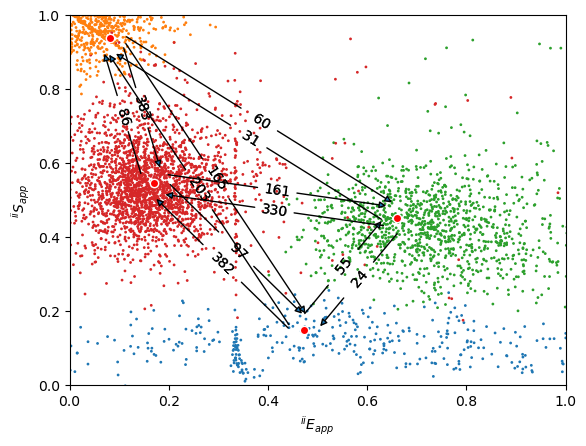

In [10]:
# plot dwell based parameters
smf.plot.scatter(data, dhmm['E_bg'], dhmm['S_bg'], 
                 point_func=smf.plot.colorcategory, point_cols=dhmm['State'], 
                 s=1.0, point_kwargs={'cmap':mpl.colormaps['tab10']})

# overlay with state locations and transition rate arrows
bhm.plot.scatter_model(dhmm['E_bg'], dhmm['S_bg'], dhmm['statepath'], data=data,
                       c='r', ec='w')
bhm.plot.scatter_model_trans_arrows(dhmm['E_bg'], dhmm['S_bg'], 
                                    statepath=dhmm['statepath'], data=data)

# ensure reasonable range is plotted (a few dwells often have extreme values)
plt.xlim([0,1])
plt.ylim([0,1]);

The `StatePath` table (*not* `Dwells`) has a column similar to the state column.
This is "bstates", which identifies which states are present using a bit code.

This column can be used to present a burst-based plot where each burst is colored by the state(s) present within it.

To make naming states and setting colors easier, `burstH2MM` has the 
`bhm.plot.make_bstate_cmap()` and `bhm.plot.state_labels_bstate()` functions.

> **Note**
>
> For those who want to dig into the details within matplotlib and colormaps,
> see the matplotlib pages
> [Colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html),
> [Creating Colormaps](https://matplotlib.org/stable/users/explain/colors/colormap-manipulation.html),
> and in particular, the input to cmap should be a
> [ListedColorMap](https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.ListedColormap.html)

The basic idea is
1. Give a name to each state, should be in order of states in model
2. Choose a color for each state, also in order of states in model
3. (optional) create an order array-
   the `order[i]`<sup>th</sup> element should be the index into `state` that should appear in the i<sup>th</sup> position
    - Note that the order in the H<sup>2</sup>MM model is always in reverse order of prevalence, so it is likely
      that the desired order will be reversed.

In [11]:
dhmm['Bstates'] = smf.Column(dhmm['statepath'], 'bstates')

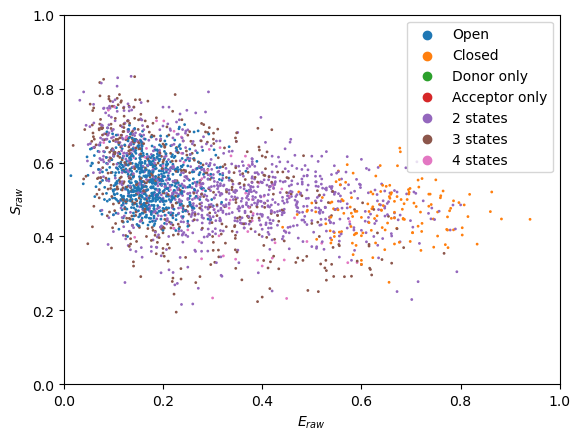

In [12]:
# inputs for make_bstate_cmap, name according to the dwell based plot, allows re-assiging colors etc.
state_names = ['Acceptor only', 'Donor only', 'Closed', 'Open']
state_colors = mpl.colormaps['tab10'].colors
state_order = [3, 2, 1, 0]
# call make_bstate_cmap
dcmap, bcmap, nlist = bhm.plot.make_bstate_cmap(state_names, state_colors, 
                                                order=state_order)

# plot burst-based plot
smf.plot.scatter(data, dbs['E_raw'], dbs['S_raw'], s=1, 
                 point_func=smf.plot.colorcategory, 
                 point_cols=dhmm['Bstates'], point_kwargs={'cmap':bcmap})
# helper function to add labels
bhm.plot.state_labels_bursts(nlist, bcmap, order=state_order)
plt.legend()
plt.xlim([0,1.0])
plt.ylim([0,1.0]);

The other color map also allows recoloring the dwell map:

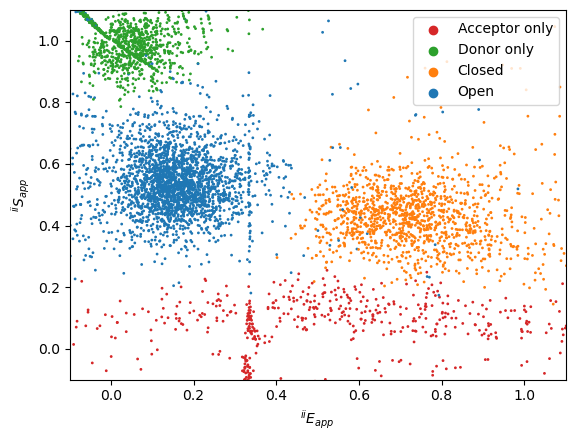

In [13]:
smf.plot.scatter(data, dhmm['E_bg'], dhmm['S_bg'], s=1.0,
                 point_func=smf.plot.colorcategory, 
                 point_cols=dhmm['State'], 
                 point_kwargs={'cmap':dcmap})
bhm.plot.state_labels_dwells(nlist, dcmap, order=state_order)
plt.legend()
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1]);

#### Retrieving model values

The model has 3 arrays:
1. prior - the probability of starting in a given state
2. trans - the probability of a transition between `[to state, from state]`
3. obs - the probability of emiting a photon in a given state, organized `[state, index]`

The optimized model is stored in the 'model' parameter of the `StatePath` `Param`:

In [14]:
dhmm['statepath'].params['model']

nstate: 4, ndet: 3, nphot: 0, niter: 0, loglik: -inf converged state: 0x8000
prior:
0.09180008464206446, 0.14192610716122736, 0.24635708795371888, 0.5199167202429893
trans:
0.9999680044027129, 1.0152488816594678e-05, 2.7462697332324526e-06, 1.909683873726998e-05
8.25172258984347e-06, 0.9999696220598387, 2.9887631522342066e-06, 1.913745441912435e-05
1.1785218691734586e-06, 1.530851813100379e-06, 0.9999807905734902, 1.6500052827459896e-05
4.8608409182432066e-06, 4.309626662595637e-06, 8.074038970015473e-06, 0.9999827554934492
obs:
0.07804743236692008, 0.07009259344021249, 0.8518599741928675
0.8592637589574251, 0.077001560515273, 0.06373468052730169
0.153134712641781, 0.2986820101455996, 0.5481832772126195
0.45271986441892176, 0.09304328947196071, 0.4542368461091176

The trans array has units of inverse macrotime clock.
The obs are the streams, so these can be interpreted similar intensities. 

`burstH2MM` provides a number of ways to transform these somewhat obtuse quantities into numbers that correspond to specific columns.

To convert transition rates into units of seconds, there is the `transrate` table property.

In [15]:
statepaths[3].transrate(data)

array([[1.99993601e+07, 2.03049776e+02, 5.49253947e+01, 3.81936775e+02],
       [1.65034452e+02, 1.99993924e+07, 5.97752630e+01, 3.82749088e+02],
       [2.35704374e+01, 3.06170363e+01, 1.99996158e+07, 3.30001057e+02],
       [9.72168184e+01, 8.61925333e+01, 1.61480779e+02, 1.99996551e+07]])

Since raw emission properties are rather hard to interpret, and states are typically defined by ratios, the `model_value` and `model_values`
parammethods implement conversion of model values to the expected equivalent.

In [16]:
dhmm['statepath'].model_values(dbs['E_raw'], dbs['S_raw'])

(array([0.47315095, 0.08224331, 0.66106896, 0.17048291]),
 array([0.14814003, 0.93626532, 0.45181672, 0.54576315]))

Note that it is using `transrate` and `model_values` that the 
`bhm.plot.scatter_model()` and `bhm.plot.scatter_model_trans_arrows()` functions retrieve their values.

Not all columns can be assigned values.
All ratio-based columns can, however nph columns can't, 
since the number of photons in a burst is not only determined by emission probability, but also the variable duration of the burst.
Similarly, since H<sup>2</sup>MM has not information (in the clasic scheme) on nanotimes,
nanomean and nanohist columns also cannot be accessed with the `model_values` parammethod.

## Error Analysis

There are 2 main ways to assess error of an H<sup>2</sup>MM model.

1. loglikelihood
2. bootstrap

In the loglikelihood method, the model is adjusted until it the loglikelihood is reduced by some amount, typically 0.5.
This must be done per parameter, which always mean adjusting at least 2 values in a given array, since all model arrays are row stochastic (sum to 1).

In the bootstrap method, n optimizations are run on n subsets of the data, and the variance of each parameter is compared.
Because each subset allows all parameters to vary, the errors of all parameters can be computed simultameously.

For computing with the loglikelihood method, we use the `bhm.error.statepath_ll_error()` function.
It returns 2 values, the first is the lower bound, the second the upper bound.


In [17]:
perrlow, perrhigh = bhm.error.statepath_ll_error(data, dhmm['statepath'],
                                                 adjust='prior')

np.array([[perrlow[i].prior[i], perrhigh[i].prior[i]] 
          for i in range(perrlow.shape[0])])

array([[0.10121535, 0.50000481],
       [0.15230788, 0.50000348],
       [0.25974069, 0.50000504],
       [0.4999936 , 0.53734135]])

In [18]:
terrlow, terrhigh = bhm.error.statepath_ll_error(data, dhmm['statepath'], 
                                                 adjust='trans')

np.array([[[terrlow[i,j].trans[i,j], terrhigh[i,j].trans[i,j]] 
           for j in range(terrlow.shape[1])] for i in range(terrlow.shape[0])])

array([[[9.99966969e-01, 9.99969019e-01],
        [9.45262811e-06, 1.08744109e-05],
        [2.23406897e-06, 3.29271908e-06],
        [1.81448522e-05, 2.00718534e-05]],

       [[7.58536109e-06, 8.94001193e-06],
        [9.99968639e-01, 9.99970586e-01],
        [2.45181691e-06, 3.55171232e-06],
        [1.82147384e-05, 2.00811439e-05]],

       [[9.24842345e-07, 1.45014167e-06],
        [1.26774926e-06, 1.80731084e-06],
        [9.99980207e-01, 9.99981364e-01],
        [1.59361406e-05, 1.70761279e-05]],

       [[4.60982339e-06, 5.11809499e-06],
        [4.07436487e-06, 4.55085423e-06],
        [7.78160635e-06, 8.37142926e-06],
        [9.99982329e-01, 9.99983176e-01]]])

In [19]:
oerrlow, oerrhigh = bhm.error.statepath_ll_error(data, dhmm['statepath'], 
                                                 adjust='obs')

np.array([[[oerrlow[i,j].obs[i,j], oerrhigh[i,j].obs[i,j]] 
           for j in range(oerrlow.shape[1])] for i in range(oerrlow.shape[0])])

array([[[0.07583581, 0.08027792],
        [0.06830048, 0.07190634],
        [0.84906987, 0.85463916]],

       [[0.85664811, 0.86186527],
        [0.07525927, 0.07876522],
        [0.06160773, 0.06588829]],

       [[0.15158204, 0.154695  ],
        [0.29685881, 0.30051276],
        [0.5462329 , 0.55013122]],

       [[0.45131276, 0.45412852],
        [0.09227517, 0.09381265],
        [0.45287635, 0.45559266]]])

To compute the boostrap method, we use the `bhm.error.BootStrapError.evaluate()` classmethod to create a 
`bhm.error.BootStrapError` object that contains the optimized models, and from which the standard deviations and errors of each model array can be retrieved.

In [20]:
err = bhm.error.BootStrapError.evaluate(data, statepaths[3], n=10)

err.err_prior, err.err_trans, err.err_obs

The model converged after 176 iterations
The model converged after 200 iterations
The model converged after 304 iterations
The model converged after 237 iterations
The model converged after 310 iterations
The model converged after 174 iterations
The model converged after 175 iterations
The model converged after 243 iterations
The model converged after 456 iterations
The model converged after 323 iterations


(array([0.00605974, 0.00951431, 0.01199174, 0.0141201 ]),
 array([[1.16488516e-06, 9.19095931e-07, 4.87602023e-07, 1.48728644e-06],
        [7.92211225e-07, 2.22718045e-06, 6.49603650e-07, 2.61210630e-06],
        [1.55352216e-07, 3.12707665e-07, 1.00957449e-06, 1.00588642e-06],
        [2.77011551e-07, 4.55167509e-07, 5.73257401e-07, 8.19386765e-07]]),
 array([[0.07483015, 0.00221965, 0.07609387],
        [0.07440479, 0.001425  , 0.07434516],
        [0.00128172, 0.00170453, 0.0025162 ],
        [0.00200295, 0.00064494, 0.00183823]]))

## Simulations

The `bhm.sim.H2MMSim` param allows creating a Monte-Carlo simulation of the photon emissions based on a H<sup>2</sup>MM model.
The simulation mimics a `bhm.StatePath` so the params and parents are the same (with the addition of a random number generator seed).
The photon emission times are fixed by the initial data, and thus will match those of the original data.
The Monte-Carlo simulation takes these times and first generates a statepath for those times,
and then assigns photon types based on said statepath.
It should be noted that photons are defined by the type of photon sorting.


There is a single parent:
- 'bursts' a `smf.Bursts` based Param, defining the bursts over which to simulate

The params are
- 'seed' an integer defining the randon number generator seed
- all parms of `bhm.StatePath` (defining the photon sorting)


Creating a `bhm.sim.H2MMSim` allows assessing the quallity of an H<sup>2</sup>MM model.
The results of `bhm.StatePath` and `bhm.sim.H2MMSim` (with the same model) should be comparable.

`bhm.sim.H2MMSim` functions like a `smf.photondata.BasePhotonTable`, 
and more specifically a subclass of `bhm.StatePath`.
However, the base is the 'bursts' parent
It "overwrites" the 'ph_...' columns, (except 'ph_times') and thus all columns derived from these recieve new values.

Below we create a simulation, generate the default columns, and plot the background corrected E and S histogram, sortin by burst state.

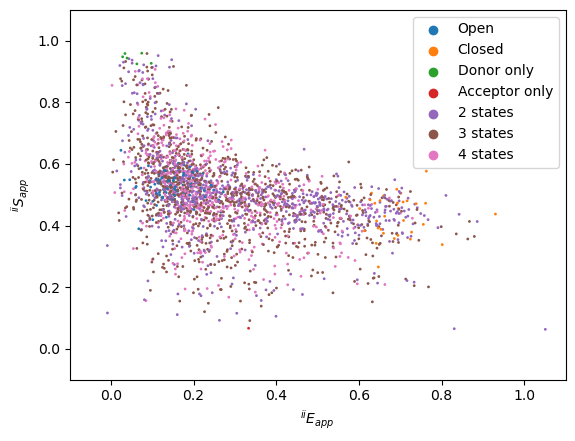

In [21]:
sim = smf.Param(bhm.sim.H2MMSim, 
                params={k:v for k, v in 
                        chain(statepaths[3].params.items(), # replicate parms of StatePath 
                              (('seed', 73), ))}, 
                parents={'bursts':dbs['bursts']}) # add seed
dsim = smf.fretfactory.make_fret_from_base(sim)
dsim['Bstates'] = smf.Column(sim, 'bstates')

smf.plot.scatter(data, dsim['E_bg'], dsim['S_bg'], s=1.0, 
                 point_func=smf.plot.colorcategory, point_cols=dsim['Bstates'],
                 point_kwargs={'cmap':bcmap})
bhm.plot.state_labels_bursts(nlist, bcmap, order=state_order)
plt.legend()
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1]);

We can also generate a `bhm.Dwells` param from the `bhm.sim.H2MMSim`, since it is a sublcass of `bhm.modeltables.StatePathBase`,
which we can then plot the simulated well based E-S plot as well:

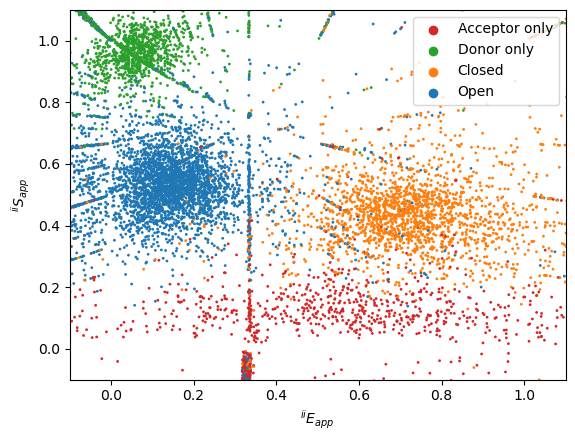

In [22]:
simdwell = smf.Param(bhm.sim.SimDwells, statepath=sim)
dsimdw = smf.fretfactory.make_fret_from_base(simdwell)
dsimdw['State'] = smf.Column(simdwell, 'state')

smf.plot.scatter(data, dsimdw['E_bg'], dsimdw['S_bg'], s=1.0, 
                 point_func=smf.plot.colorcategory, 
                 point_cols=dsimdw['State'], 
                 point_kwargs={'cmap':dcmap})
bhm.plot.state_labels_dwells(nlist, dcmap, order=state_order)
plt.legend()
plt.xlim([-0.1,1.1])
plt.ylim([-0.1,1.1]);

Don't forget to print the citations:

In [23]:
smf.print_citations()

1. Ingargiola, A., Lerner, E., Chung, S. Y., Weiss, S. & Michalet, X.
    FRETBursts: An open source toolkit for analysis of freely-diffusing Single-
    molecule FRET. PLoS ONE 11, 1–27 (2016).
2. Müller, B. K., Zaychikov, E., Bräuchle, C. & Lamb, D. C. Pulsed interleaved
    excitation. Biophysical Journal 89, 3508–3522 (2005).
3. Nir, E. et al. Shot-noise limited single-molecule FRET histograms: Comparison
    between theory and experiments. Journal of Physical Chemistry B 110,
    22103–22124 (2006).
4. Eggeling, C., Fries, J. R., Brand, L., Günther, R. & Seidel, C. A. M.
    Monitoring conformational dynamics of a single molecule by selective
    fluorescence spectroscopy. Proc. Natl. Acad. Sci. U.S.A. 95, 1556–1561
    (1998).
5. Torella, J. P., Holden, S. J., Santoso, Y., Hohlbein, J. & Kapanidis, A. N.
    Identifying molecular dynamics in single-molecule fret experiments with
    burst variance analysis. Biophysical J. 100, 1568–1577 (2011).
6. Pirchi, M. et al. Photon-by-Phot

The cell below saves the statepath params to an HDF5 file,
allowing us to open the optimizations again later.
This way we don't need to re-run the optimizations.

In [24]:
import tables as tb

with tb.open_file('data/statepathparams.hdf5', 'w') as f:
    dgroup = f.create_group(f.root, 'HP3_TE300_SPC630')
    modelsgroup = f.create_group(dgroup, 'statepath_params')
    for statepath in statepaths:
        statepath.encode_group(modelsgroup, f'opt_{statepath.model.ndet}d_{statepath.model.nstate}s')

Thus concludes the basic $\mathrm{H^{2}MM}$ tutorial.